In [ ]:
import pandas as pd
import yfinance as yf
import datetime as dt
import requests
import time

def fetch_integrated_dataset(days=730):
    end_date = dt.date.today()
    print(end_date)
    start_date = end_date - dt.timedelta(days=days)

    # --- 1. 获取市场价格数据 (Yahoo Finance) ---
    symbols = {
        "LTC": "LTC-USD", "XRP": "XRP-USD", "ETH": "ETH-USD", "DOGE": "DOGE-USD",
        "Gold": "GC=F", "Silver": "SI=F", "Oil": "CL=F",
        "SP500": "^GSPC", "NASDAQ": "^IXIC", "DXY": "DX-Y.NYB",
        "Treasury_10Y": "^TNX", "EUR": "EURUSD=X", "JPY": "JPYUSD=X"
    }

    print(f"[INFO] 正在获取价格数据...")
    try:
        btc = yf.download("BTC-USD", start=start_date, end=end_date)
        if isinstance(btc.columns, pd.MultiIndex): btc.columns = btc.columns.get_level_values(0)

        main_df = btc[['Open', 'Close', 'High', 'Low', 'Volume']].copy()
        main_df.columns = ['BTC_Open', 'BTC_Close', 'BTC_High', 'BTC_Low', 'BTC_Volume']
        # 确保索引是标准的 DatetimeIndex
        main_df.index = pd.to_datetime(main_df.index)
    except Exception as e:
        print(f"[ERROR] BTC 数据获取失败: {e}")
        return None
    # 获取其他资产
    for name, ticker in symbols.items():
        temp = yf.download(ticker, start=start_date, end=end_date, progress=False)
        if not temp.empty:
            if isinstance(temp.columns, pd.MultiIndex): temp.columns = temp.columns.get_level_values(0)
            col = "Adj Close" if "Adj Close" in temp.columns else "Close"
            main_df[f"{name}_close"] = temp[col]

    # --- 2. 获取链上技术特征 (b) ---
    onchain_metrics = {
        "Active_addr_cnt": "n-unique-addresses",
        "Xfer_cnt": "n-transactions",
        "Mean_hash_rate": "hash-rate",
        "Difficulty": "difficulty",
        "Total_fees_USD": "transaction-fees-usd",
        "Mean_block_size": "avg-block-size"
    }

    print("[INFO] 正在获取链上数据...")
    for col_name, api_slug in onchain_metrics.items():
        try:
            url = f"https://api.blockchain.info/charts/{api_slug}?timespan=all&format=json&cors=true"
            resp = requests.get(url, timeout=15)
            if resp.status_code == 200:
                data = resp.json()
                df_temp = pd.DataFrame(data['values'])
                df_temp['x'] = pd.to_datetime(df_temp['x'], unit='s')
                df_temp = df_temp.set_index('x')['y'].rename(col_name)
                # 关键修复：确保链上数据索引也是 DatetimeIndex
                df_temp.index = pd.to_datetime(df_temp.index)
                # 重采样并填充，确保每一天都有值
                df_temp = df_temp.resample('D').mean().ffill()
                # 合并
                main_df = main_df.join(df_temp, how='left')
                print(f"      - {col_name}: 成功")
            time.sleep(0.5)
        except Exception as e:
            print(f"      [WARN] {col_name} 失败: {e}")

    # --- 3. 生成衍生时间特征 (h) ---
    print("[INFO] 正在生成日期哑变量...")
    # 确保 main_df.index 拥有 weekday 属性
    main_df.index = pd.to_datetime(main_df.index)

    days_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    for i, day in enumerate(days_names):
        # 修正：使用 .index.weekday 获取星期索引 (0=Monday)
        main_df[day] = (main_df.index.weekday == i).astype(int)

    # --- 4. 数据后处理 ---
    main_df = main_df.ffill().bfill()
    return main_df

dataset = fetch_integrated_dataset(days=1460)
if dataset is not None:
    out_file = "Macro_BTC_Dataset.xlsx"
    dataset.to_excel(out_file)
    print("-" * 30)
    print(f"任务完成！")
    print(f"文件保存至: {out_file}")
    print(f"最终特征总数: {dataset.shape[1]}")
    print(f"日期范围: {dataset.index.min()} 至 {dataset.index.max()}")
    print("-" * 30)

In [1]:
from utils import *
np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120

Number of monthly observations: 1460
First 10 observations: [40553.4648 40424.4844 39716.9531 40826.2148 41502.75   41374.3789
 40527.3633 39740.3203 39486.7305 39469.293 ]
Last 10 observations: [67290.5156 68981.8984 68859.8281 71940.7031 71123.3594 71767.8281
 72979.0469 73054.2734 70753.4062 74484.6406]


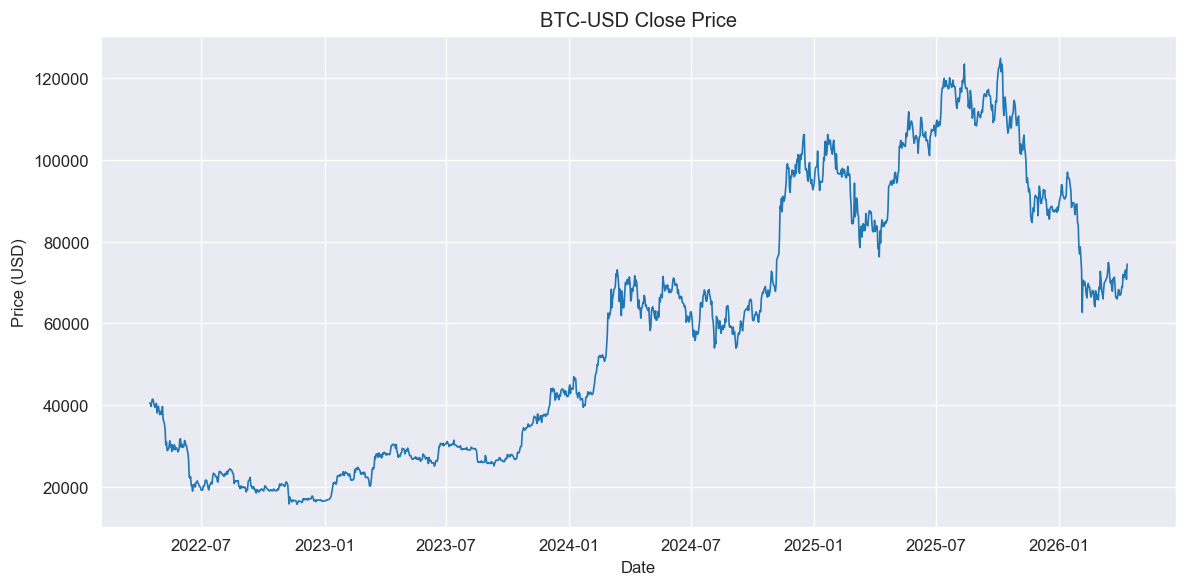

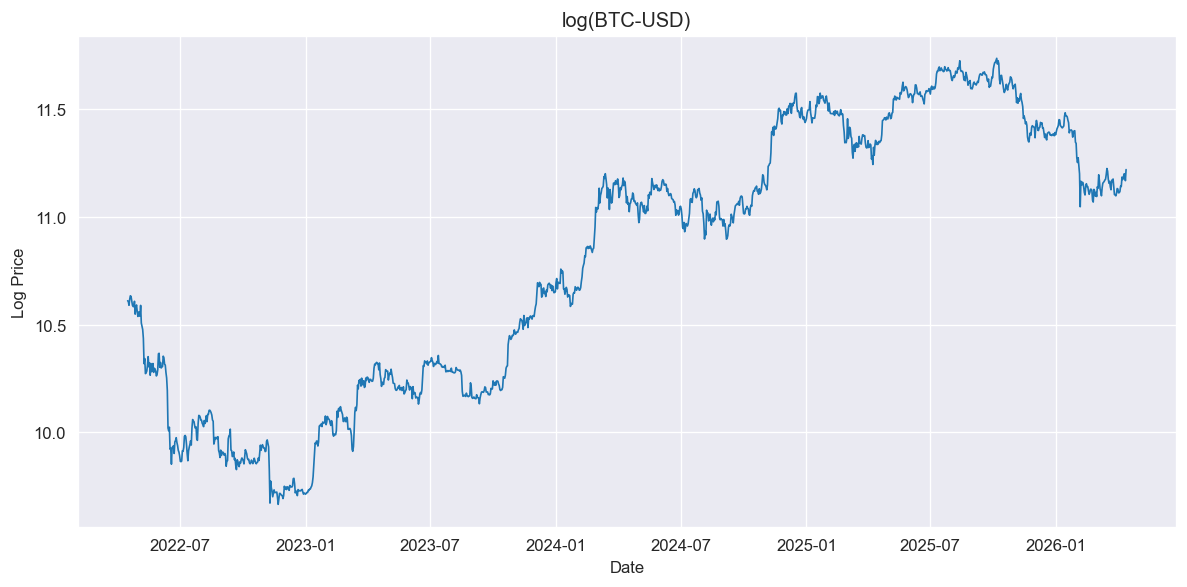

In [2]:
BTC_data=pd.read_excel("Macro_BTC_Dataset.xlsx","Sheet1")
BTC_data.head(10)
BTC_series=BTC_data["BTC_Close"].to_numpy().T.reshape(-1).astype(float)
date_series=BTC_data["Date"].to_list()
BTC_series_len = len(BTC_series)

print("Number of monthly observations:", BTC_series_len)
print("First 10 observations:", BTC_series[:10])
print("Last 10 observations:", BTC_series[-10:])

btc_series_with_date = pd.Series(BTC_series, index=pd.to_datetime(date_series))
plot_series(btc_series_with_date, "BTC-USD Close Price", xlabel="Date", ylabel="Price (USD)", savefile="graphs/BTC-USD Close Price.png")
log_btc_series = np.log(btc_series_with_date)
plot_series(log_btc_series, "log(BTC-USD)", xlabel="Date", ylabel="Log Price", savefile="graphs/BTC-USD Log Price.png")

Unit root test summary: level series


E:\Python_projects\AI-6123- TimeSeriesAna\TSA-Project\utils.py:199: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")
E:\Python_projects\AI-6123- TimeSeriesAna\TSA-Project\utils.py:199: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")


,series,test,stat,pvalue,usedlag
0,BTC_series,ADF (constant),-0.911011,0.784325,1
1,BTC_series,KPSS (constant),4.929500,0.010000,25
2,BTC_series,ADF (constant + trend),-1.809649,0.700087,1
3,BTC_series,KPSS (constant + trend),0.424951,0.010000,25


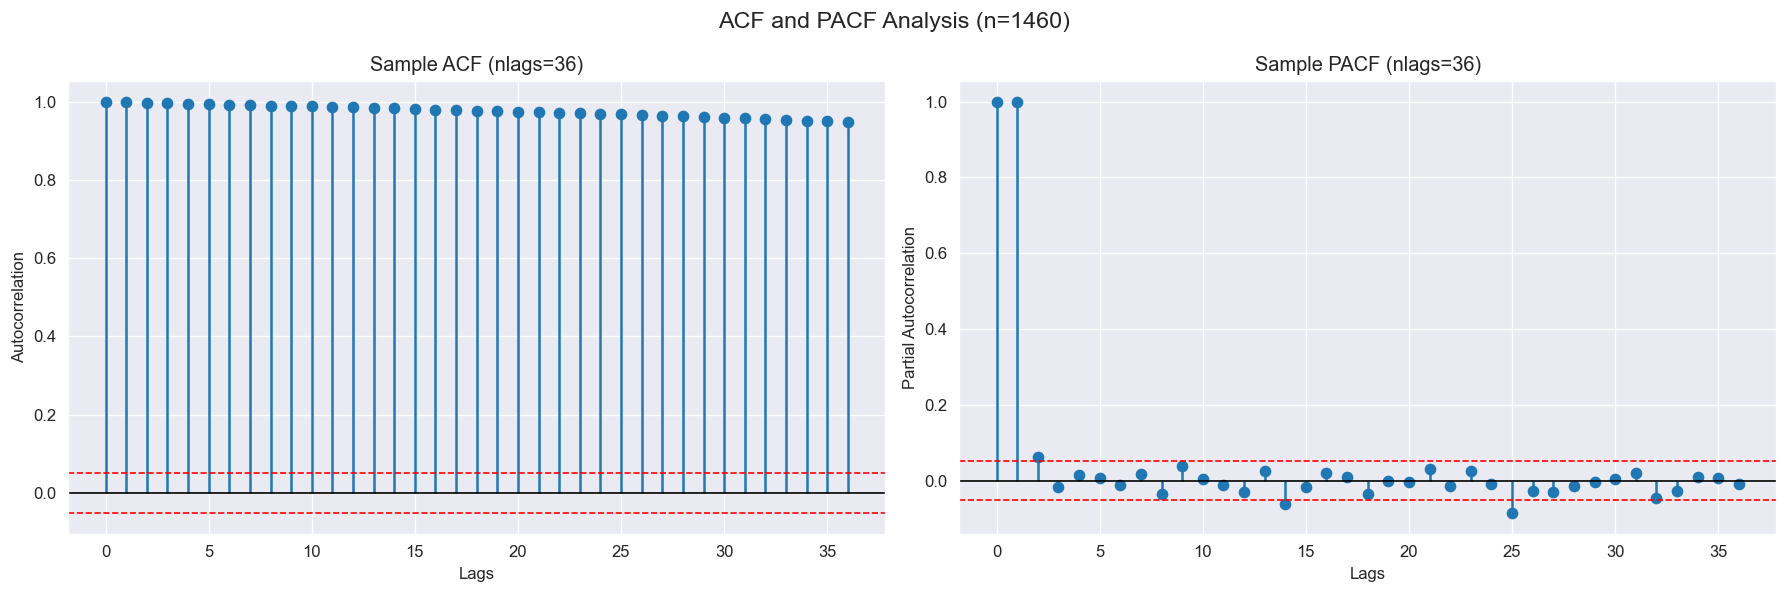

(array([1.    , 0.9986, 0.9974, 0.9961, 0.9949, 0.9936, 0.9924, 0.9912,
        0.9899, 0.9887, 0.9875, 0.9863, 0.9851, 0.9839, 0.9825, 0.9811,
        0.9797, 0.9784, 0.977 , 0.9756, 0.9741, 0.9728, 0.9714, 0.9701,
        0.9688, 0.9672, 0.9656, 0.9638, 0.9621, 0.9604, 0.9586, 0.957 ,
        0.9552, 0.9533, 0.9515, 0.9497, 0.9479]),
 array([ 1.    ,  0.9986,  0.0628, -0.0166,  0.0159,  0.0069, -0.0109,
         0.0165, -0.0347,  0.0387,  0.0053, -0.0111, -0.0307,  0.0253,
        -0.0626, -0.0164,  0.0198,  0.0087, -0.0351, -0.0023, -0.0041,
         0.0293, -0.0152,  0.026 , -0.0095, -0.0859, -0.0282, -0.0296,
        -0.0154, -0.0048,  0.0048,  0.0205, -0.0452, -0.0264,  0.009 ,
         0.0064, -0.0081]))

In [3]:
print("Unit root test summary: level series")
display(unit_root_summary(BTC_series, name="BTC_series"))
plot_acf_pacf(BTC_series, nlags=36,savefile=f"graphs/BTC-USD-acf-PACF.png")

Unit root test summary: log series


E:\Python_projects\AI-6123- TimeSeriesAna\TSA-Project\utils.py:199: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")
E:\Python_projects\AI-6123- TimeSeriesAna\TSA-Project\utils.py:199: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")


,series,test,stat,pvalue,usedlag
0,log(BTC_series),ADF (constant),-0.717468,0.842173,2
1,log(BTC_series),KPSS (constant),5.093314,0.010000,25
2,log(BTC_series),ADF (constant + trend),-2.420974,0.368529,2
3,log(BTC_series),KPSS (constant + trend),0.504990,0.010000,25


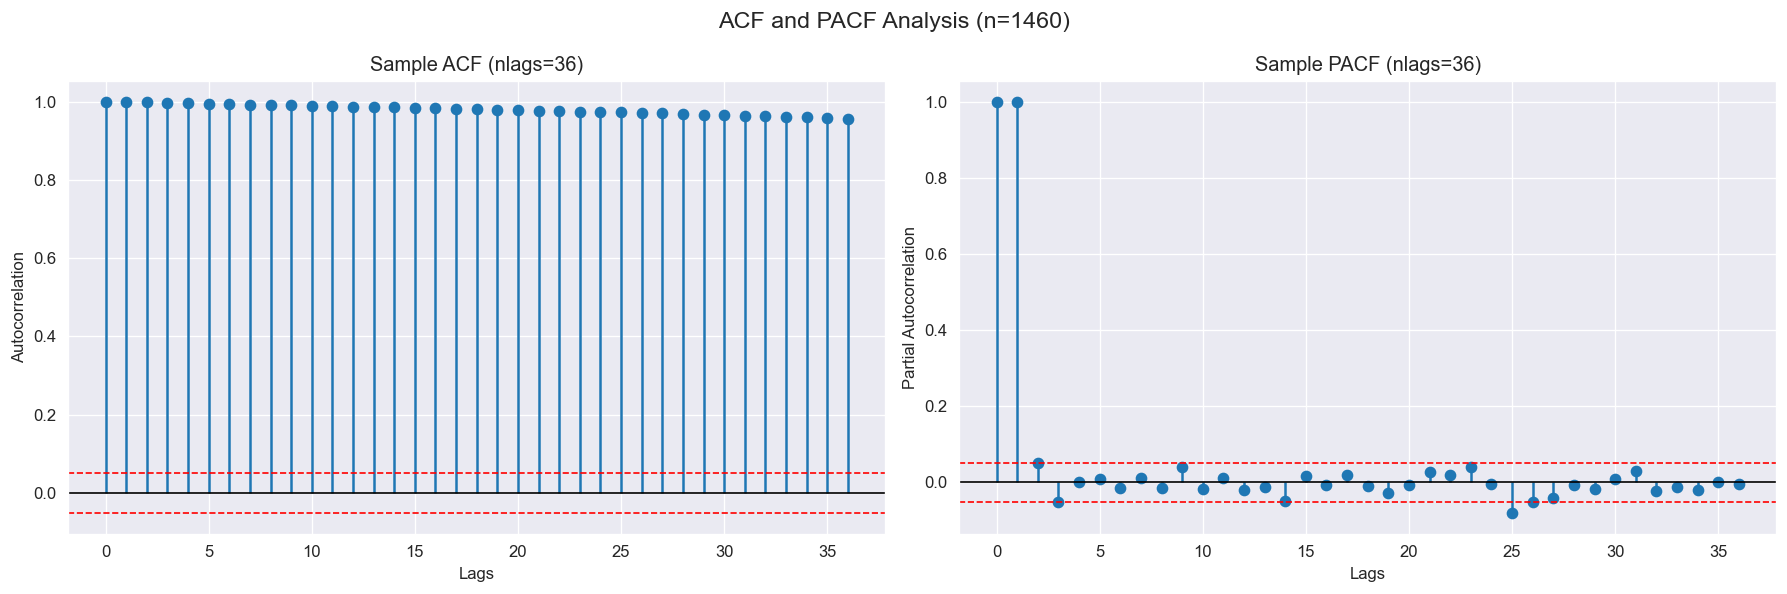

(array([1.    , 0.9989, 0.9979, 0.9968, 0.9957, 0.9946, 0.9935, 0.9925,
        0.9914, 0.9903, 0.9893, 0.9882, 0.9872, 0.9861, 0.9849, 0.9837,
        0.9826, 0.9814, 0.9803, 0.9791, 0.9778, 0.9767, 0.9756, 0.9745,
        0.9735, 0.9723, 0.971 , 0.9696, 0.9682, 0.9668, 0.9653, 0.9639,
        0.9625, 0.9611, 0.9596, 0.9582, 0.9567]),
 array([ 1.    ,  0.9989,  0.0522, -0.0527,  0.0007,  0.0103, -0.0146,
         0.0122, -0.0141,  0.0406, -0.0178,  0.0104, -0.0189, -0.0125,
        -0.048 ,  0.0161, -0.0066,  0.0199, -0.0088, -0.0269, -0.0066,
         0.028 ,  0.0199,  0.0408, -0.0045, -0.0806, -0.0515, -0.0402,
        -0.0062, -0.0184,  0.0083,  0.0301, -0.0221, -0.0132, -0.0201,
         0.0021, -0.0044]))

In [4]:
print("Unit root test summary: log series")
display(unit_root_summary(np.log(BTC_series), name="log(BTC_series)"))
plot_acf_pacf(np.log(BTC_series), nlags=36,savefile=f"graphs/log-BTC-USD-acf-PACF.png")

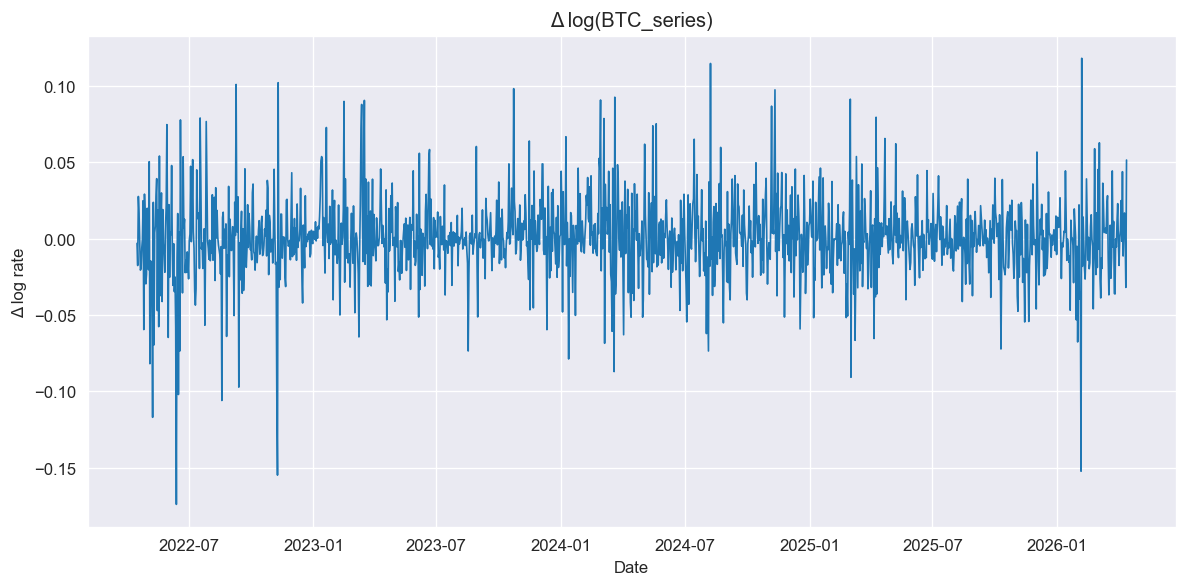

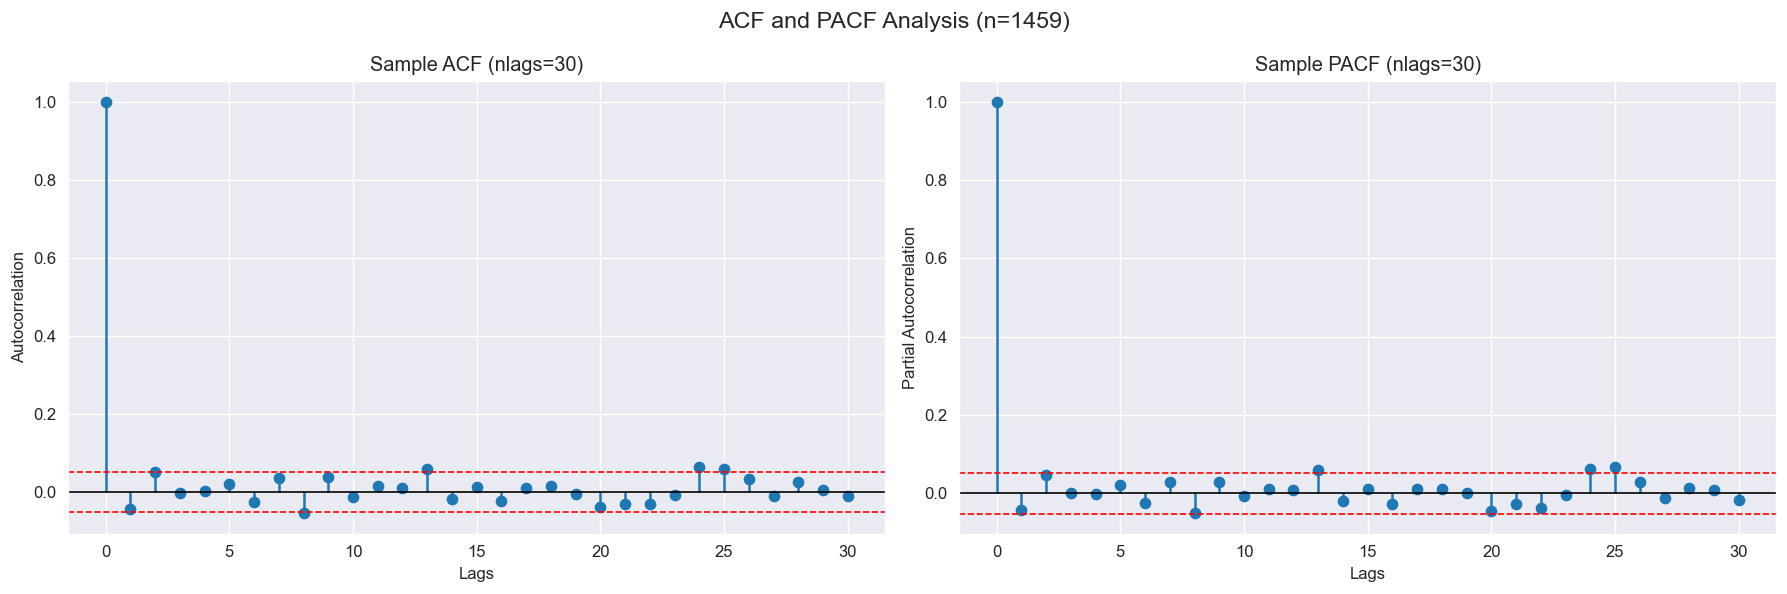

Unit root test summary: Δ log(BTC_series)


E:\Python_projects\AI-6123- TimeSeriesAna\TSA-Project\utils.py:199: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")
E:\Python_projects\AI-6123- TimeSeriesAna\TSA-Project\utils.py:199: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")


,series,test,stat,pvalue,usedlag
0,dlBTC_series,ADF (constant),-26.242973,0.00,1
1,dlBTC_series,KPSS (constant),0.227049,0.10,5
2,dlBTC_series,ADF (constant + trend),-26.237386,0.00,1
3,dlBTC_series,KPSS (constant + trend),0.223064,0.01,5


In [5]:
dlBTC_series = np.diff(np.log(BTC_series))
dl_dates = pd.to_datetime(date_series[1:])

dlBTC_series_pd = pd.Series(dlBTC_series, index=dl_dates)
plot_series(dlBTC_series_pd, "Δ log(BTC_series)", xlabel="Date", ylabel="Δ log rate",savefile='graphs/Δ log(BTC_series).png')

plot_acf_pacf(dlBTC_series_pd, nlags=30, savefile='graphs/Δ log(BTC_series) acf-PACF.png')
print("Unit root test summary: Δ log(BTC_series)")
display(unit_root_summary(dlBTC_series_pd, name="dlBTC_series"))


图片已保存至: graphs\LB_Heatmap_W7.png


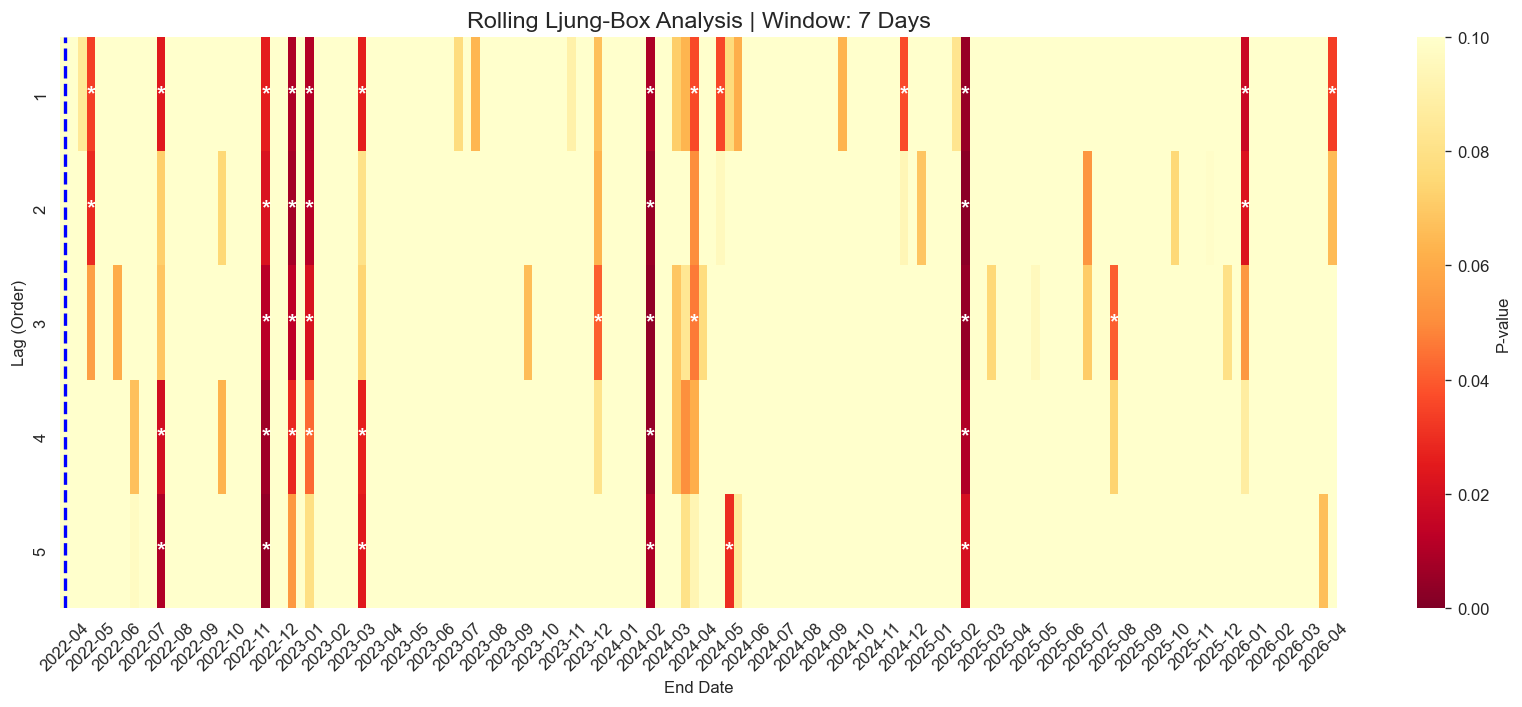

图片已保存至: graphs\LB_Heatmap_W30.png


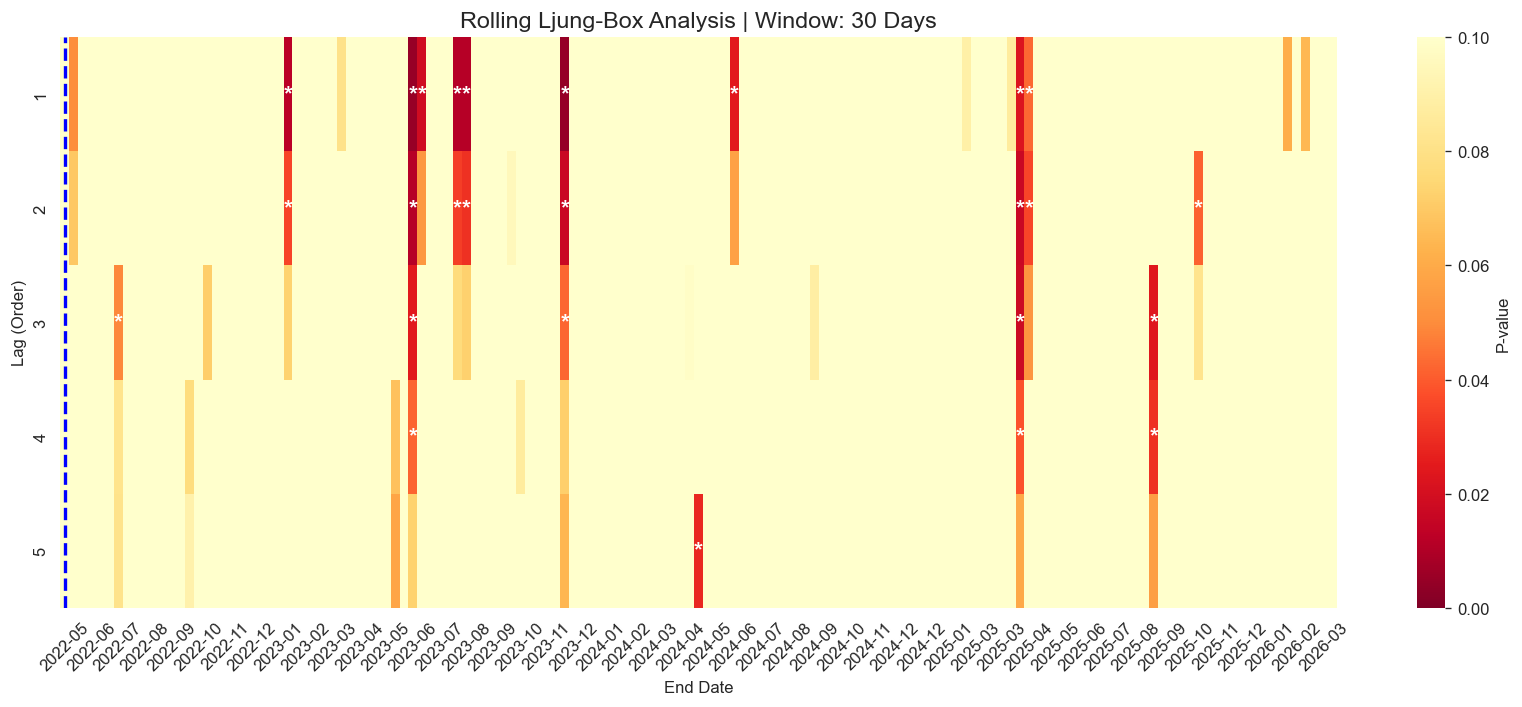

图片已保存至: graphs\LB_Heatmap_W180.png


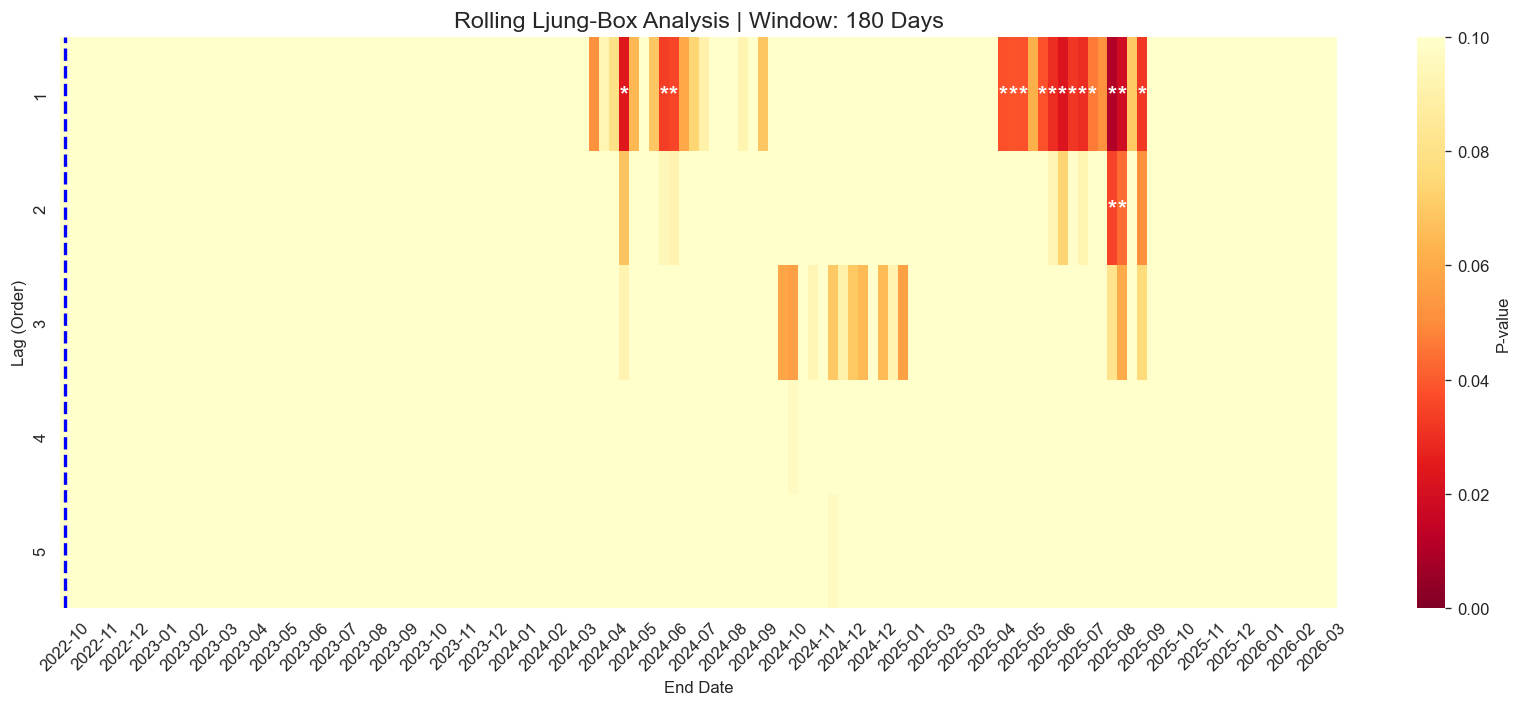

图片已保存至: graphs\LB_Heatmap_W365.png


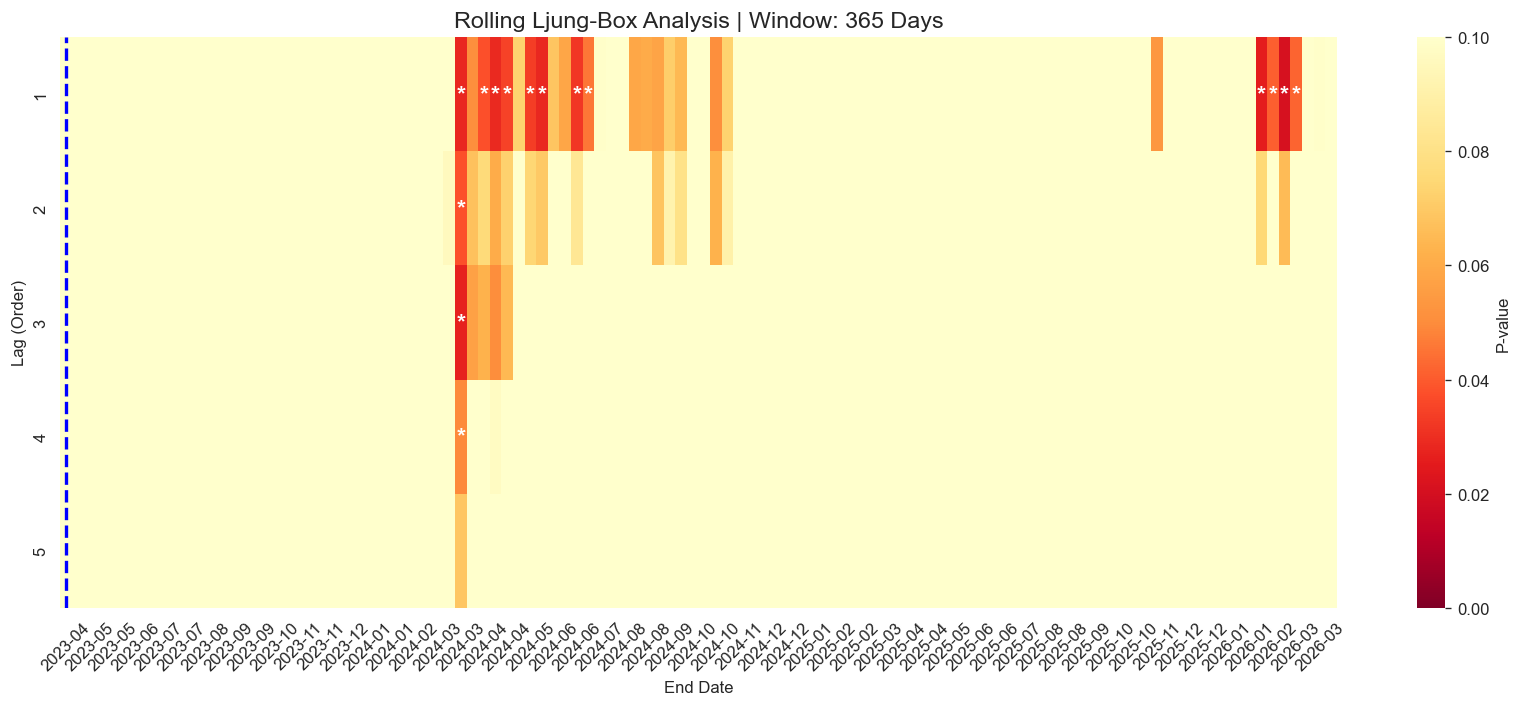

图片已保存至: graphs\LB_Heatmap_W730.png


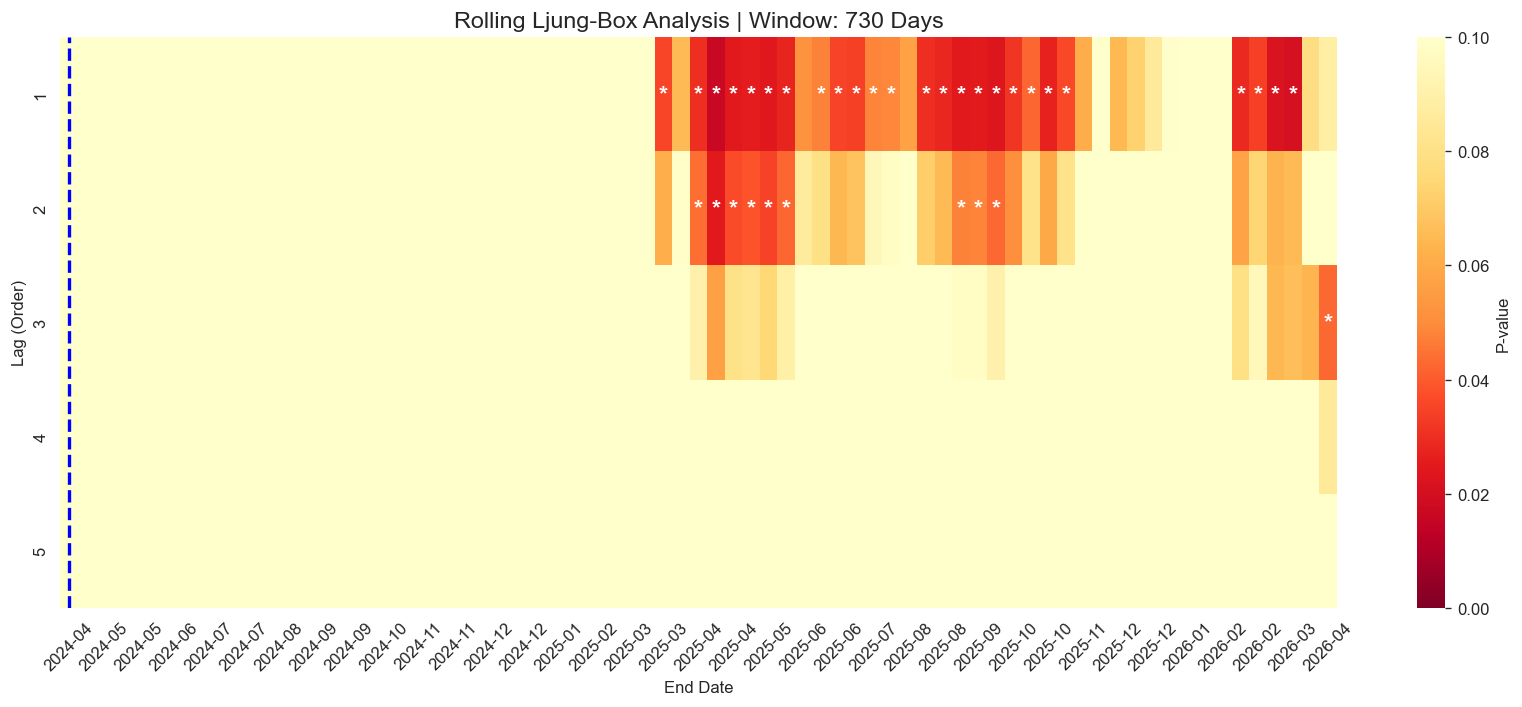

In [30]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def rolling_ljungbox_heatmap(series, window_size, max_lag=15):
    all_p = []
    dates = []
    for i in range(0, len(series) - window_size, 10): # 每隔10天取样一次，避免图太挤
        window_data = series.iloc[i : i + window_size]
        test_res = acorr_ljungbox(window_data, lags=max_lag, return_df=True)
        all_p.append(test_res['lb_pvalue'].values)
        dates.append(series.index[i + window_size].strftime('%Y-%m'))

    return pd.DataFrame(all_p, index=dates, columns=range(1, max_lag + 1)).T

def plot_and_save_to_folder(series, windows=[30, 180, 365], max_lag=5, custom_path="my_btc_analysis"):
    """
    custom_path: 你可以指定绝对路径（如 'D:/Project/Figures'）或相对路径（如 'output/plots'）
    """
    # 1. 确保文件夹存在（支持多级目录）
    if not os.path.exists(custom_path):
        os.makedirs(custom_path)
        print(f"已创建文件夹: {os.path.abspath(custom_path)}")

    for w in windows:
        data = rolling_ljungbox_heatmap(series, window_size=w, max_lag=max_lag)
        if data.empty:
            continue
        plt.figure(figsize=(14, 6))
        annot_mask = data.applymap(lambda x: '*' if (not np.isnan(x) and x < 0.05) else '')

        sns.heatmap(data, cmap='YlOrRd_r', vmin=0, vmax=0.1, annot=annot_mask, fmt='',
                    annot_kws={'size': 14, 'weight': 'bold'}, cbar_kws={'label': 'P-value'})

        plt.axvline(x=0.5, color='blue', linestyle='--', linewidth=2)
        plt.title(f'Rolling Ljung-Box Analysis | Window: {w} Days', fontsize=14)
        plt.ylabel('Lag (Order)')
        plt.xlabel('End Date')
        plt.xticks(rotation=45)
        plt.tight_layout()
        save_name = f"LB_Heatmap_W{w}.png"
        full_save_path = os.path.join(custom_path, save_name)
        plt.savefig(full_save_path, dpi=300, bbox_inches='tight')
        print(f"图片已保存至: {full_save_path}")

        plt.show()

# --- 调用示例 ---
# 你可以指定任意文件夹名称
out_folder = "graphs"
plot_and_save_to_folder(dlBTC_series_pd, windows=[7, 30, 180, 365, 730], max_lag=5, custom_path=out_folder)

## 短窗口可能有相关性，但容易被噪声误导
## 长窗口在某一阶段可能有较稳固的相关性，但对短期预测帮助不大 (信息迟滞)


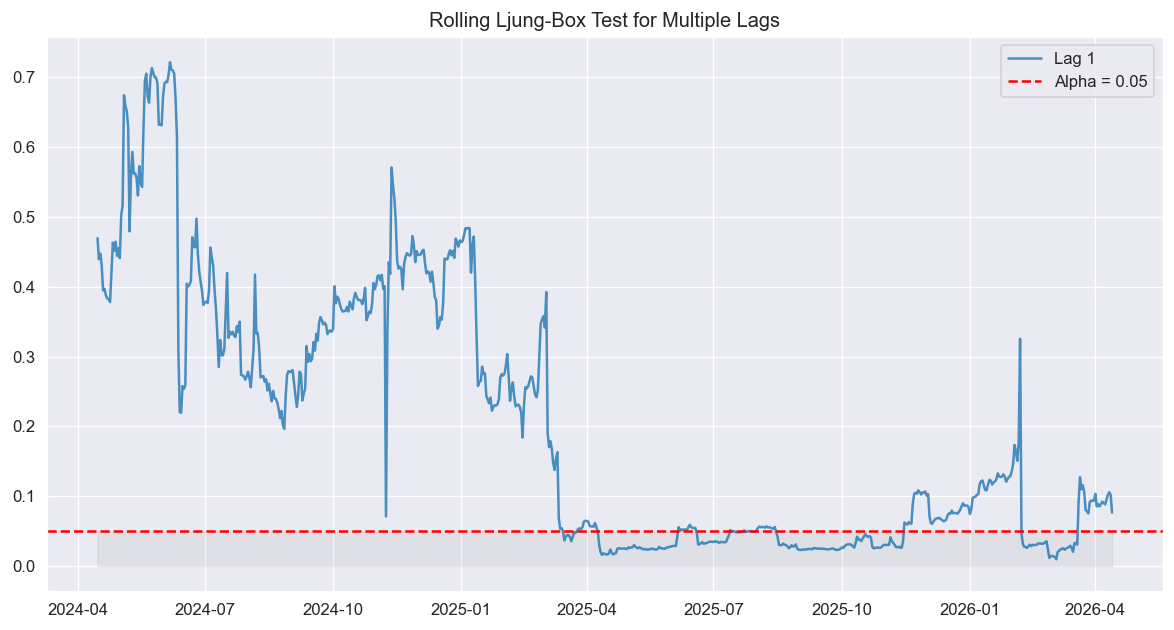

In [32]:
def rolling_ljungbox_multi(series, window_size, lags=[1]):
    results = {}
    for lag in lags:
        p_values = []
        dates = []
        for i in range(0, len(series) - window_size):
            window_data = series.iloc[i : i + window_size]
            test_res = acorr_ljungbox(window_data, lags=[lag], return_df=True)
            p_values.append(test_res.loc[lag, 'lb_pvalue'])
            dates.append(series.index[i + window_size])
        results[f'Lag {lag}'] = pd.Series(p_values, index=dates)
    return pd.DataFrame(results)

# 运行并绘图
multi_p = rolling_ljungbox_multi(dlBTC_series_pd, window_size=730)

plt.figure(figsize=(12, 6))
for column in multi_p.columns:
    plt.plot(multi_p.index, multi_p[column], label=column, alpha=0.8)

plt.axhline(y=0.05, color='red', linestyle='--', label='Alpha = 0.05')
plt.fill_between(multi_p.index, 0, 0.05, color='gray', alpha=0.1)
plt.title('Rolling Ljung-Box Test for Multiple Lags')
plt.legend()
plt.show()

In [66]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def prepare_selective_lag_data(df, forecast_horizon=5, btc_lags=3):
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.sort_values('Date').set_index('Date')
    df['BTC_log_ret'] = np.log(df['BTC_Close']).diff()

    asset_cols = [c for c in df.columns if '_close' in c and 'BTC' not in c]
    for col in asset_cols:
        df[f'{col}_ret'] = np.log(df[col]).diff()

    cols_to_fill = [c for c in df.columns if 'ret' in c or 'cnt' in c or 'Fees' in c]
    df[cols_to_fill] = df[cols_to_fill].ffill()

    for i in range(1, btc_lags + 1):
        df[f'BTC_ret_lag{i}'] = df['BTC_log_ret'].shift(i)

    macro_features = ['SP500_close_ret', 'NASDAQ_close_ret', 'DXY_close_ret', 'Gold_close_ret']
    onchain_cols = ['Active_addr_cnt', 'Xfer_cnt', 'Total_fees_USD', 'Difficulty']
    cols_to_lag = macro_features + onchain_cols
    lags_n = 3

    for col in cols_to_lag:
        if col in df.columns:
            for i in range(1, lags_n + 1):
                df[f'{col}_lag{i}'] = df[col].shift(i)

    for k in range(1, forecast_horizon + 1):
        df[f'target_{k}d'] = df['BTC_log_ret'].shift(-k)

    return df.dropna()

def reduce_collinearity(df, features, threshold=5.0):
    curr_features = features.copy()
    while True:
        vif_data = [variance_inflation_factor(df[curr_features].values, i)
                    for i in range(len(curr_features))]
        max_vif = max(vif_data)
        if max_vif > threshold:
            # 剔除 VIF 最大的那个特征
            drop_idx = vif_data.index(max_vif)
            print(f"Dropping {curr_features[drop_idx]} with VIF: {max_vif:.2f}")
            curr_features.pop(drop_idx)
        else:
            break
    return curr_features


processed_data=prepare_selective_lag_data(BTC_data)
print(processed_data.head(10))
print(processed_data.columns)


                BTC_Open     BTC_Close      BTC_High       BTC_Low  \
Date                                                                 
2022-04-19  40828.175781  41502.750000  41672.960938  40618.632812   
2022-04-20  41501.746094  41374.378906  42126.300781  40961.097656   
2022-04-21  41371.515625  40527.363281  42893.582031  40063.828125   
2022-04-22  40525.863281  39740.320312  40777.757812  39315.417969   
2022-04-23  39738.722656  39486.730469  39935.859375  39352.203125   
2022-04-24  39478.375000  39469.292969  39845.925781  39233.539062   
2022-04-25  39472.605469  40458.308594  40491.753906  38338.378906   
2022-04-26  40448.421875  38117.460938  40713.890625  37884.984375   
2022-04-27  38120.300781  39241.121094  39397.917969  37997.312500   
2022-04-28  39241.429688  39773.828125  40269.464844  38941.421875   

             BTC_Volume   LTC_close  XRP_close    ETH_close  DOGE_close  \
Date                                                                      
2022-04-1

Dropping Difficulty_lag1 with VIF: 2496.20
Dropping Difficulty_lag2 with VIF: 1865.12
Dropping Difficulty with VIF: 421.11
Dropping Tuesday with VIF: 16.98
Dropping Active_addr_cnt_lag2 with VIF: 13.42
Dropping Xfer_cnt_lag1 with VIF: 12.85
Dropping Active_addr_cnt_lag1 with VIF: 10.62
Dropping Xfer_cnt_lag2 with VIF: 9.61
Dropping Difficulty_lag3 with VIF: 6.57
Dropping Active_addr_cnt with VIF: 104.09
Dropping Xfer_cnt_lag3 with VIF: 24.42
Dropping NASDAQ_close_ret with VIF: 15.61
Dropping NASDAQ_close_ret_lag2 with VIF: 15.38
Dropping SP500_close_ret_lag1 with VIF: 15.31
Dropping NASDAQ_close_ret_lag3 with VIF: 15.27
Dropping Active_addr_cnt_lag3 with VIF: 9.73
Dropping Total_fees_USD_lag2 with VIF: 6.72


Text(0.5, 1.0, 'Feature Correlation Map')

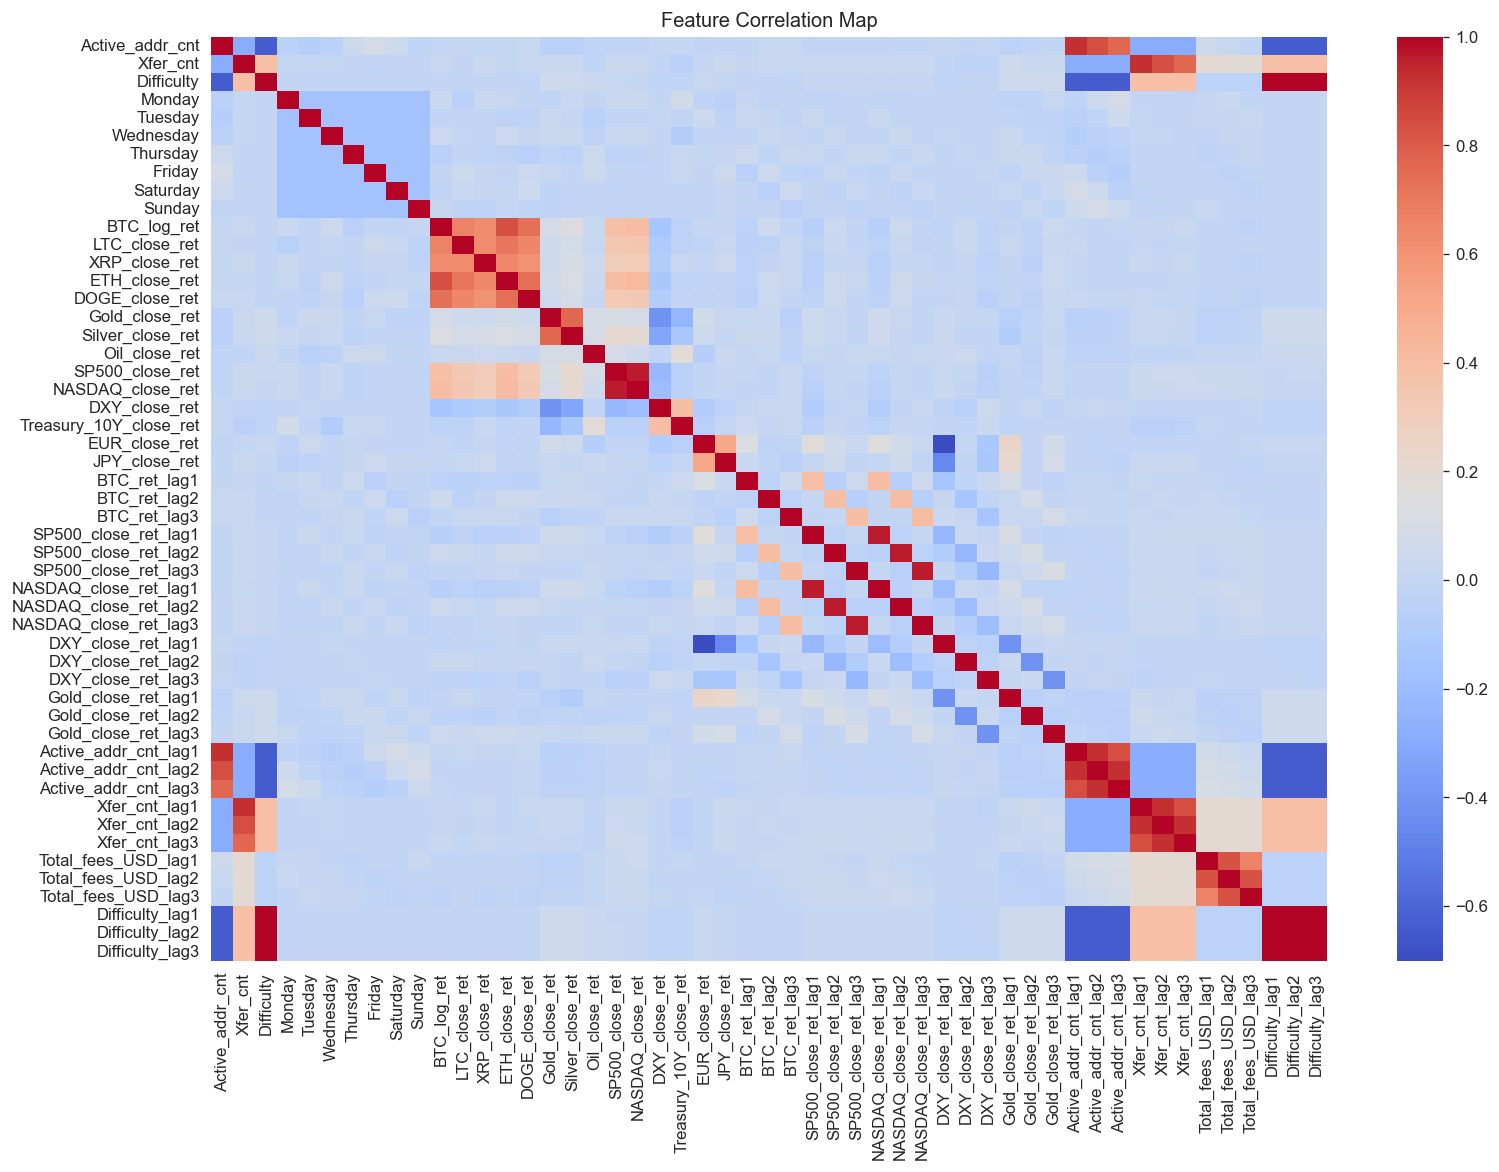

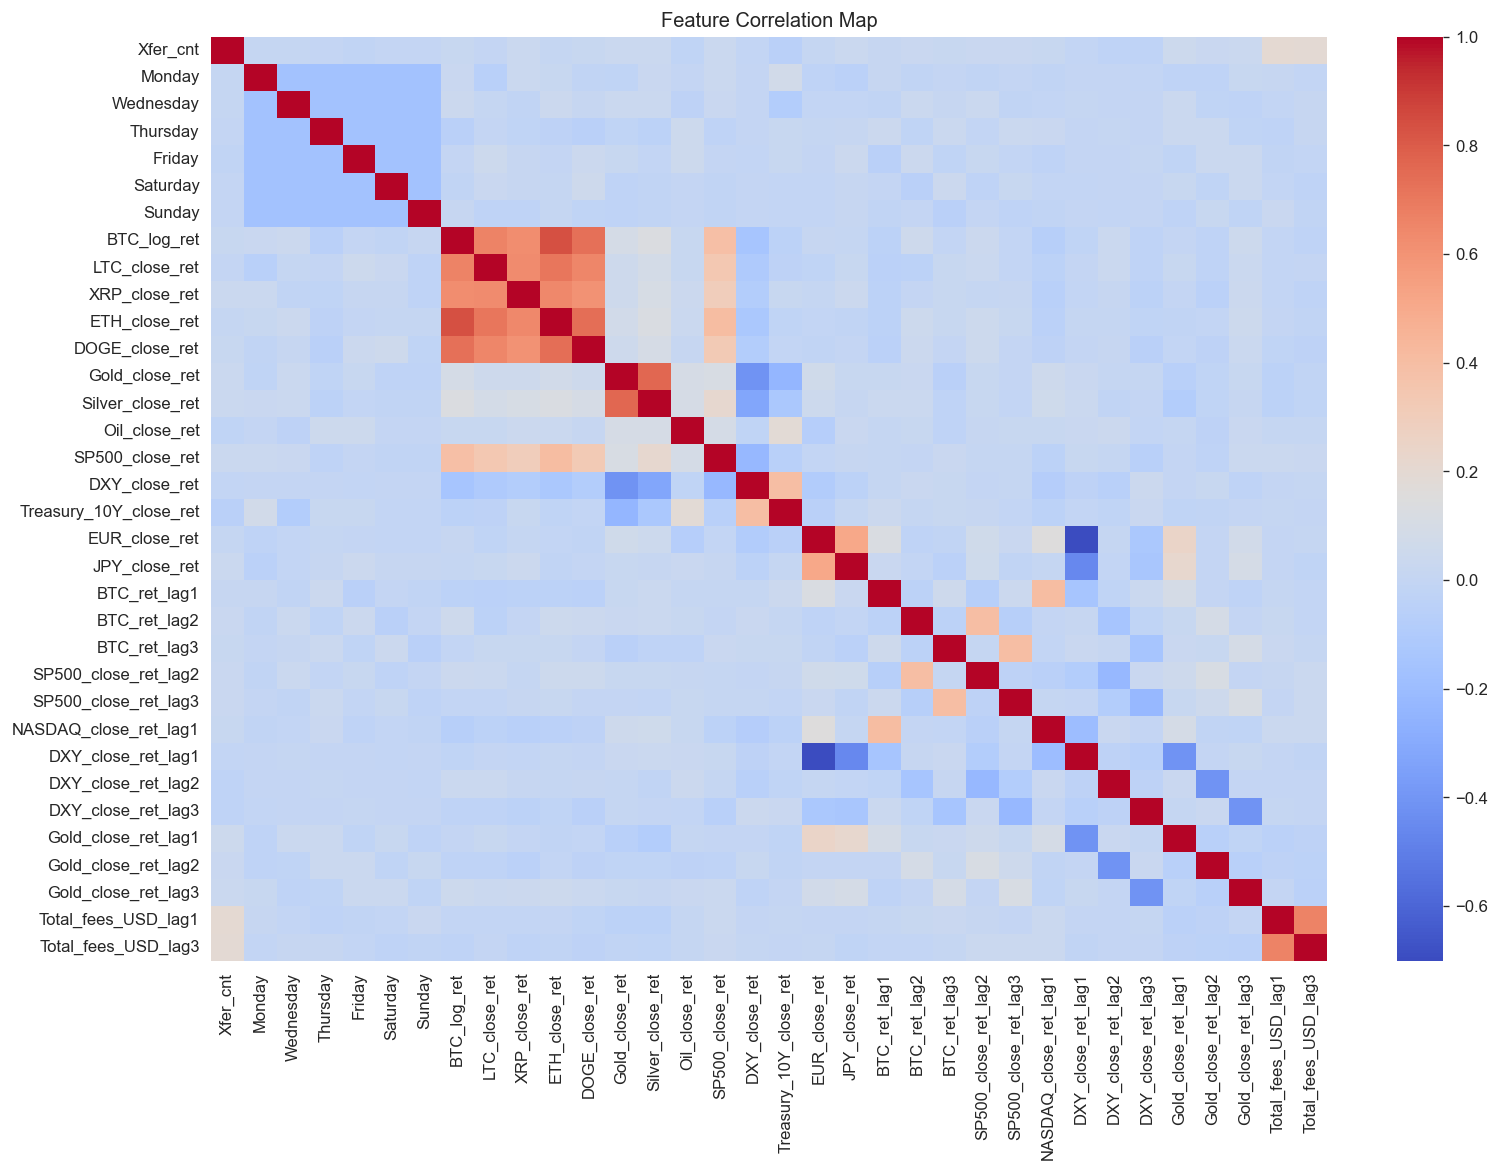

In [68]:
features = [c for c in processed_data.columns if any(k in c for k in ['ret', 'lag', 'Active', 'Xfer', 'Fees', 'Difficulty','Monday', 'Tuesday', 'Wednesday', 'Thursday','Friday', 'Saturday', 'Sunday']) and 'target' not in c]

plt.figure(figsize=(15, 10))
sns.heatmap(processed_data[features].corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Map")

new_features=reduce_collinearity(processed_data,features, threshold=5.0)

plt.figure(figsize=(15, 10))
sns.heatmap(processed_data[new_features].corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Map")



In [73]:
print(processed_data.tail(20))

                BTC_Open     BTC_Close      BTC_High       BTC_Low  \
Date                                                                 
2026-03-20  69911.531250  70522.585938  71346.796875  69398.882812   
2026-03-21  70522.468750  68711.523438  71051.273438  68602.914062   
2026-03-22  68737.445312  67845.210938  69561.773438  67372.875000   
2026-03-23  67843.000000  70914.859375  71782.257812  67458.843750   
2026-03-24  70912.671875  70517.859375  71371.304688  68920.695312   
2026-03-25  70520.046875  71309.882812  71985.742188  70383.593750   
2026-03-26  71310.117188  68791.625000  71410.390625  68118.351562   
2026-03-27  68790.835938  66338.375000  69117.531250  65532.570312   
2026-03-28  66338.500000  66319.695312  67232.859375  65906.742188   
2026-03-29  66319.695312  65954.921875  67052.953125  64971.707031   
2026-03-30  65958.351562  66691.445312  68087.289062  65759.804688   
2026-03-31  66694.585938  68233.312500  68495.273438  65950.437500   
2026-04-01  68232.89

In [69]:
import torch.nn as nn

class TinyLSTM(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, 32, batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        # x shape: (Batch, Seq_len, Features)
        out, _ = self.lstm(x)
        # 只取最后一个时间步的输出
        return self.fc(out[:, -1, :])

def train_lstm_step(X_train, y_train, X_test):
    # 1. 局部归一化 (针对当前 window_size)
    scaler_x = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_s = scaler_x.fit_transform(X_train)
    y_train_s = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
    X_test_s = scaler_x.transform(X_test)

    # 2. 转换为张量
    X_tensor = torch.FloatTensor(X_train_s).unsqueeze(0) # (1, window_size, features)
    y_tensor = torch.FloatTensor(y_train_s).unsqueeze(0)

    model = TinyLSTM(X_train_s.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()

    # 3. 快速训练 (20-30 epochs 即可收敛)
    model.train()
    for _ in range(25):
        optimizer.zero_grad()
        output = model(X_tensor)
        loss = criterion(output, y_tensor[:, -1, :])
        loss.backward()
        optimizer.step()

    # 4. 预测
    model.eval()
    with torch.no_grad():
        X_test_tensor = torch.FloatTensor(X_test_s).unsqueeze(0)
        pred_s = model(X_test_tensor)
        pred_ret = scaler_y.inverse_transform(pred_s.numpy())[0][0]

    return pred_ret


In [74]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from arch import arch_model
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn


def rolling_forecast_multistep_plus(df, window_size, forecast_horizon=5, model_type='XGB',
                                   features=None, train_gap_step=1, eval_days=60, target_date='2026-04-14'):
    results = []
    if features is None:
        features = [c for c in df.columns if any(k in c for k in ['ret', 'lag', 'Active', 'Xfer', 'Fees', 'Difficulty']) and 'target' not in c]
    target_dt = pd.to_datetime(target_date)
    start_eval_dt = target_dt - pd.Timedelta(days=eval_days)
    try:
        start_idx = df.index.get_indexer([start_eval_dt], method='pad')[0]
    except:
        start_idx = len(df) - eval_days - forecast_horizon

    target_dt = pd.to_datetime(target_date)
    # 找到目标日期在 df 中的位置
    try:
        end_idx = df.index.get_indexer([target_dt], method='pad')[0]
    except:
        end_idx = len(df) - 1

    actual_start = max(window_size, start_idx)
    print(f"[截断模式] 评价目标: {target_date} | 评价区间: {eval_days}天")
    print(f"训练窗口: {window_size}天 | 实际起始索引: {actual_start} (共需滚动 {end_idx - actual_start} 次)")
    models_cache = {k: None for k in range(1, forecast_horizon + 1)}

    for i in range(actual_start, end_idx+1):
        # ... (内部训练与预测逻辑保持不变) ...
        is_retrain_day = (i - actual_start) % train_gap_step == 0
        test_row = df.iloc[[i]]
        day_preds_ret, day_preds_price = {}, {}
        base_price = df.iloc[i]['BTC_Close']
        current_pred_price = base_price

        for k in range(1, forecast_horizon + 1):
            y_col = f'target_{k}d'

            if model_type == 'LSTM':
                # LSTM 每一天都基于当前窗口重新训练 (或按 train_gap_step)
                if is_retrain_day:
                    X_tr, y_tr = df.iloc[i-window_size:i][features], df.iloc[i-window_size:i][y_col]
                    X_ts = test_row[features]
                    pred_ret = train_lstm_step(X_tr, y_tr, X_ts)
                    # 缓存当天的预测值，供 gap复用
                    day_preds_ret[f'Pred_Ret_{k}d'] = pred_ret
                else:
                    pred_ret = results[-1][f'Pred_Ret_{k}d'] if results else 0

            else:
                if is_retrain_day or models_cache[k] is None:
                    train_df = df.iloc[i-window_size : i]
                    X_tr, y_tr = train_df[features], train_df[y_col]
                    if model_type == 'XGB':
                        m = xgb.XGBRegressor(n_estimators=100, random_state=42).fit(X_tr, y_tr)
                        models_cache[k] = m
                    elif model_type == 'RF':
                        m = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_tr, y_tr)
                        models_cache[k] = m
                    elif model_type == 'ARMAX_GARCH':
                        try:
                            m = SARIMAX(y_tr, exog=X_tr, order=(1, 0, 1)).fit(disp=False, maxiter=200)
                            models_cache[k] = m
                        except: models_cache[k] = "MEAN_FALLBACK"
                if models_cache[k] == "MEAN_FALLBACK":
                    pred_ret = df.iloc[i-window_size:i][y_col].mean()
                elif model_type == 'ARMAX_GARCH':
                    pred_ret = models_cache[k].forecast(steps=1, exog=test_row[features])[0]
                else:
                    pred_ret = models_cache[k].predict(test_row[features])[0]

            day_preds_ret[f'Pred_Ret_{k}d'] = pred_ret
            current_pred_price *= np.exp(pred_ret) # 对数收益率还原为价格
            day_preds_price[f'Pred_Price_{k}d'] = current_pred_price
            # 安全检查：如果 i+k 超过了数据表长度，则填 NaN (即预测的是还没发生的未来)
            actual_idx = i + k
            if actual_idx < len(df):
                day_preds_ret[f'Actual_Ret_{k}d'] = df.iloc[actual_idx]['BTC_log_ret']
                day_preds_price[f'Actual_Price_{k}d'] = df.iloc[actual_idx]['BTC_Close']
            else:
                day_preds_ret[f'Actual_Ret_{k}d'] = np.nan
                day_preds_price[f'Actual_Price_{k}d'] = np.nan

        combined = {**day_preds_ret, **day_preds_price}
        combined['Forecast_Date'] = df.index[i]
        results.append(combined)

        if (i - window_size) % 50 == 0:
            print(f"Done: {model_type} | Date: {df.index[i]}")

    return pd.DataFrame(results).set_index('Forecast_Date')

def plot_target_60d_weighted_mape(all_res_dict, target_date='2026-04-20', decay=0.95, h=5):

    summary = []
    target_dt = pd.to_datetime(target_date)
    start_eval_dt = target_dt - pd.Timedelta(days=60)

    for name, res_df in all_res_dict.items():
        res_df.index = pd.to_datetime(res_df.index)
        mask = (res_df.index >= start_eval_dt) & (res_df.index <= target_dt)
        eval_df = res_df.loc[mask].copy()

        if eval_df.empty:
            print(f"警告: {name} 在评价区间内没有数据！")
            continue
        # 计算 Decay 权重
        eval_df['days_diff'] = (target_dt - eval_df.index).days
        eval_df['weight'] = eval_df['days_diff'].apply(lambda x: decay**x)

        row = {'Config': name}
        for k in range(1, h + 1):
            # 计算 APE
            ape = np.abs((eval_df[f'Actual_Price_{k}d'] - eval_df[f'Pred_Price_{k}d']) / eval_df[f'Actual_Price_{k}d'])
            # 加权平均
            w_mape = (ape * eval_df['weight']).sum() / eval_df['weight'].sum() * 100
            row[f'Day_{k}'] = w_mape
        summary.append(row)

    summary_df = pd.DataFrame(summary).set_index('Config')
    # 绘图
    plt.figure(figsize=(12, 7))
    sns.heatmap(summary_df, annot=True, cmap="YlOrRd", fmt=".2f")
    plt.title(f"Target 60-Day Weighted MAPE (Decay={decay})\nInterval: {start_eval_dt.date()} to {target_dt.date()}")
    plt.show()
    return summary_df



开始测试窗口大小: 30 天

正在训练组合: XGB_W30 (Gap=2)
[截断模式] 评价目标: 2026-04-14 | 评价区间: 60天
训练窗口: 30天 | 实际起始索引: 1396 (共需滚动 54 次)
Done: XGB | Date: 2026-03-19 00:00:00

正在训练组合: RF_W30 (Gap=2)
[截断模式] 评价目标: 2026-04-14 | 评价区间: 60天
训练窗口: 30天 | 实际起始索引: 1396 (共需滚动 54 次)
Done: RF | Date: 2026-03-19 00:00:00

正在训练组合: LSTM_W30 (Gap=1)
[截断模式] 评价目标: 2026-04-14 | 评价区间: 60天
训练窗口: 30天 | 实际起始索引: 1396 (共需滚动 54 次)
Done: LSTM | Date: 2026-03-19 00:00:00

正在训练组合: ARMAX_GARCH_W30 (Gap=2)
[截断模式] 评价目标: 2026-04-14 | 评价区间: 60天
训练窗口: 30天 | 实际起始索引: 1396 (共需滚动 54 次)
Done: ARMAX_GARCH | Date: 2026-03-19 00:00:00

开始测试窗口大小: 90 天

正在训练组合: XGB_W90 (Gap=2)
[截断模式] 评价目标: 2026-04-14 | 评价区间: 60天
训练窗口: 90天 | 实际起始索引: 1396 (共需滚动 54 次)
Done: XGB | Date: 2026-03-29 00:00:00

正在训练组合: RF_W90 (Gap=2)
[截断模式] 评价目标: 2026-04-14 | 评价区间: 60天
训练窗口: 90天 | 实际起始索引: 1396 (共需滚动 54 次)
Done: RF | Date: 2026-03-29 00:00:00

正在训练组合: LSTM_W90 (Gap=1)
[截断模式] 评价目标: 2026-04-14 | 评价区间: 60天
训练窗口: 90天 | 实际起始索引: 1396 (共需滚动 54 次)
Done: LSTM | Date: 2026-03-29 00:00:00


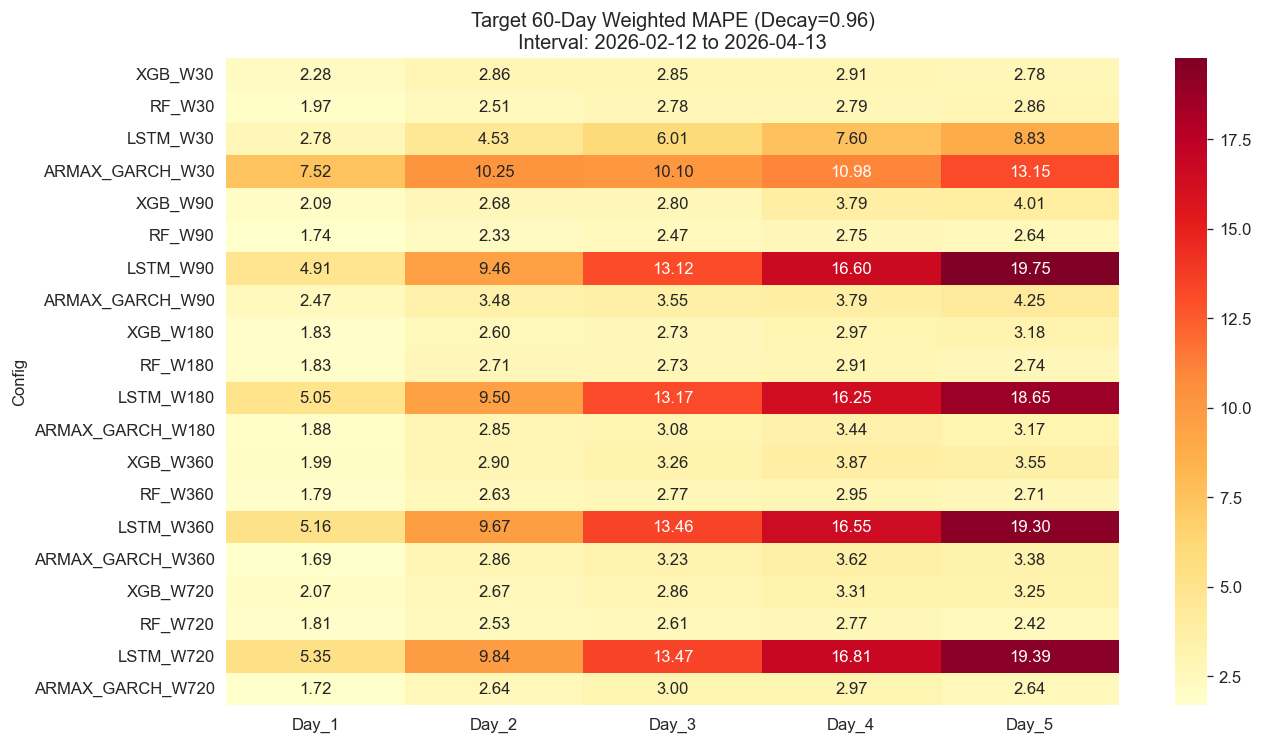


 针对今日 (4.14) 的最佳预测组合是: RF_W90


In [77]:
import warnings
# 1. 屏蔽 SARIMAX 常见的收敛和参数警告 (UserWarning)
warnings.filterwarnings("ignore", message="Non-invertible starting MA parameters found")
warnings.filterwarnings("ignore", message="Non-stationary starting autoregressive parameters")
# 2. 屏蔽 statsmodels 的频率推断警告 (ValueWarning)  我对线性模型真的不报太大期望
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels.tsa.base.tsa_model")
warnings.filterwarnings("ignore", message="Maximum Likelihood optimization failed to converge")

target_date = '2026-04-13'
h_horizon = 5
eval_days = 60
test_windows = [30, 90, 180, 360, 720]
model_types = ['XGB', 'RF', 'LSTM', 'ARMAX_GARCH']
all_experiments = {}

for w in test_windows:
    print(f"\n" + "="*30)
    print(f"开始测试窗口大小: {w} 天")
    print("="*30)
    for m in model_types:
        gap = 1 if m == 'LSTM' else 2
        exp_label = f"{m}_W{w}"
        print(f"\n正在训练组合: {exp_label} (Gap={gap})")
        res = rolling_forecast_multistep_plus(
            processed_data,
            window_size=w,
            features=new_features,
            eval_days=eval_days,
            forecast_horizon=h_horizon,
            model_type=m,
            train_gap_step=gap
        )
        all_experiments[exp_label] = res

print("\n" + "="*30)
print(f"正在生成 4.14 目标加权评估报告...")
final_mape_report = plot_target_60d_weighted_mape(
    all_experiments,
    target_date=target_date,
    decay=0.96
)
best_model = final_mape_report.mean(axis=1).sort_values().index[0]
print(f"\n 针对今日 (4.14) 的最佳预测组合是: {best_model}")

In [78]:
def calculate_btc_volatility(df, window=60):
    # 1. 确保有对数收益率
    if 'BTC_log_ret' not in df.columns:
        df['BTC_log_ret'] = np.log(df['BTC_Close']).diff()

    # 2. 取最近 60 天的数据
    recent_60d_ret = df['BTC_log_ret'].tail(window)

    # 3. 计算日均波动率 (标准差)
    daily_vol = recent_60d_ret.std()

    # 4. 计算年化波动率
    annual_vol = daily_vol * np.sqrt(365)

    print(f"--- 近 {window} 天波动率报告 ---")
    print(f"日均波动率: {daily_vol:.4f} (约 {daily_vol*100:.2f}%)")
    print(f"年化波动率: {annual_vol:.4f} (约 {annual_vol*100:.2f}%)")

    return daily_vol, annual_vol
# 调用
daily_v, annual_v = calculate_btc_volatility(processed_data)

--- 近 60 天波动率报告 ---
日均波动率: 0.0241 (约 2.41%)
年化波动率: 0.4605 (约 46.05%)
